In [3]:
#%pip install matplotlib
#%pip install pandas 

In [4]:
import os 
from pathlib import Path
import pandas as pd
import numpy as np
import sys 

import matplotlib.pyplot as plt

In [5]:
os.getcwd()

# local environments 
#os.environ["SCRATCH"] = "/home/fderrida/Desktop/mount_jz_scratch"


'/lustre/fswork/projects/rech/ldz/upr55xw/these/domainbed/DomainBed/domainbed/audio_data'

In [6]:
data_directory= Path(os.environ["SCRATCH"]) / "domainbed/data/URGENT/corpus"

In [7]:
dataset = "CommonVoice/cv-corpus-22.0-2025-06-20" # In the cluster only
#dataset = "CommonVoice/subset" # local 
data_path = Path(data_directory) / dataset

In [8]:
data_path

PosixPath('/lustre/fsn1/projects/rech/ldz/upr55xw/domainbed/data/URGENT/corpus/CommonVoice/cv-corpus-22.0-2025-06-20')

In [9]:
languages = ["fr", "de", "es", "zh-CN"] 
# languages = ["fr", "es"] 
# languages = ["fr"] 

In [ ]:
data_train = get_data_from_CV(data_path=data_path, split='train')
data_dev = get_data_from_CV(data_path=data_path, split='dev')
data_test = get_data_from_CV(data_path=data_path, split='test')

### Count number of examples in each splits

In [12]:
splits = ["train", "dev","test"]
data_map = {
    "train": data_train,
    "test": data_test,
    "dev": data_dev
}

for split in splits:
    data_obs = data_map.get(split)
    c = 0
    for l in languages: 
        c += len(data_obs[l])
    print(f"{split} split has {c} examples")

train split has 23202 examples
dev split has 10942 examples
test split has 19539 examples


### Observe distribution of examples' length

In [13]:
clip_duration_path = data_path/l/"clip_durations.tsv"

In [14]:
#splits = ['train']
splits = ["train", "dev","test"]
for split in splits:
    data_obs = data_map.get(split)
    #print(data_obs.keys())
    for l in languages: 
        clip_duration_path = data_path/l/"clip_durations.tsv"
        df = pd.read_csv(clip_duration_path, sep="\t", header=None, names=["clip", "duration[ms]"], low_memory=False)
        clip_durations = dict(zip(df["clip"], df["duration[ms]"]))
        #print(data_obs[l][0])
        for d in data_obs[l]:
            clip_id = d["path_to_mp3"].split("/")[-1]
            if clip_durations.get(clip_id, None) is not None: 
                d["duration_s"] = float(clip_durations.get(clip_id, None)) / 1000.0
            #print(clip_id)
            #print(d)

In [15]:
data_map['train']['fr'][1]

{'spk_id': 'd040fa9a2c24278faab591a797a4183b88db3a26ba40ed7b7400f5a1bb9432809bdff527cc6c91dae145a68561d97c4c327050d7af9fefdc478a5aba0f898d05',
 'path_to_mp3': '15/common_voice_fr_39601374.mp3',
 'language': 'fr',
 'duration_s': 6.552}

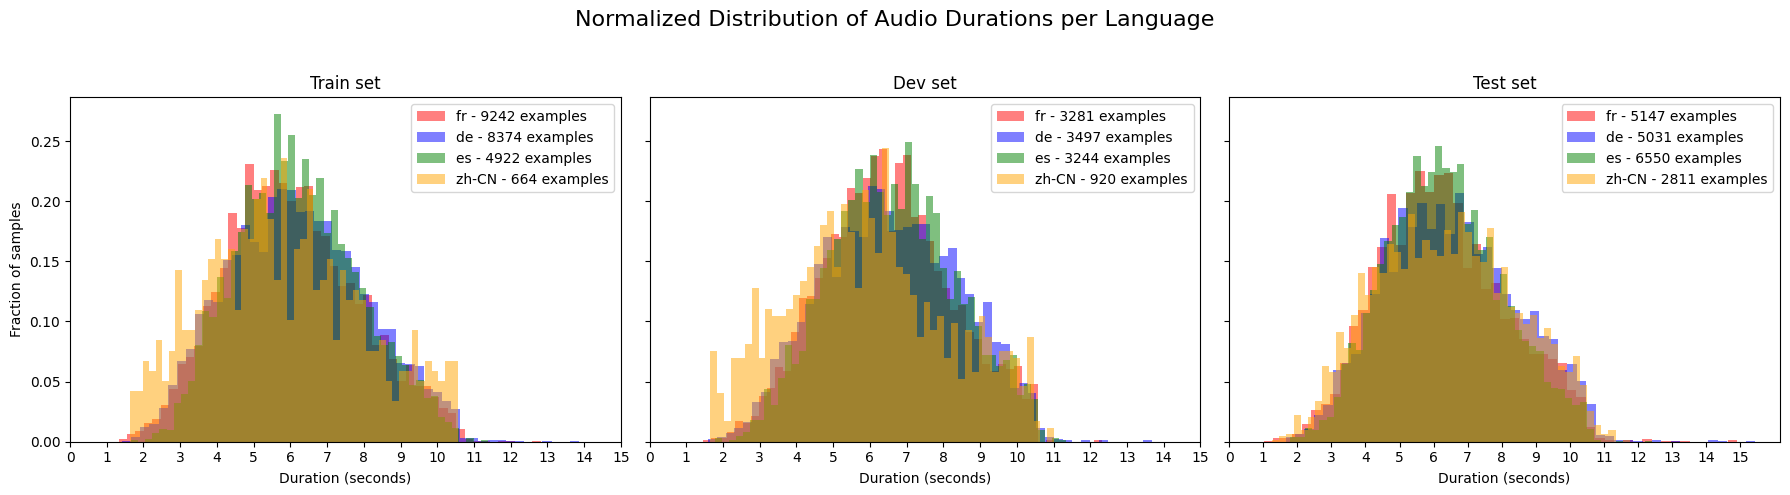

In [16]:

languages = list(data_map["train"].keys())
colors = ['red', 'blue', 'green', 'orange']  # one color per language
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # share y-axis for easier comparison

for ax, split in zip(axes, splits):    
    for i, l in enumerate(languages):
        # collect durations, ignore None
        durations = [s["duration_s"] for s in data_map[split][l] if s["duration_s"] is not None]
        
        ax.hist(durations, bins=50, alpha=0.5, color=colors[i], label=f"{l} - {len(data_map[split][l])} examples", density=True)
    
    ax.set_title(f"{split.capitalize()} set")
    ax.set_xlabel("Duration (seconds)")
    ax.set_xticks(range(0, 16))
    if ax == axes[0]:
        ax.set_ylabel("Fraction of samples")
    ax.legend()
    
plt.suptitle("Normalized Distribution of Audio Durations per Language", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

If we consider that 1 image from VLCS (3,224,224) is "equivalent" to 10s of audio sampled at 16kHz. 
All Common Voice mp3/wav files are typically 16 kHz (16,000 Hz) for recent datasets. \
Here the distribution is around \
If we consider that 1 image from VLCS (3,224,224) is to 10s of audio sampled at 16kHz. \
All Common Voice mp3/wav files are typically 16 kHz (16,000 Hz) for recent datasets. \
Here the distribution is around 6s. \
In VLCS (5 classes) there are 10.729 => 6437 examples of audio \
In PACS (7 classes) there are 9.991 => \
In Office-Home (65 classes) there are 15.588 => \
In Terra Incognita (10 classes) there are 24.788 => \


In [17]:
len(data_map[split][l])

2811

### Observe proportion of each language in the total trainset 

In [ ]:
import random as rd
from collections import defaultdict

def split_domains(
    environments,
    data,
    dataset_size,
    min_duration=3,
    seed=42
):
    rd.seed(seed)
    n_domains = len(environments)

    domains = {env: [] for env in environments}

    # Filter all splits
    filtered = {
        split: {
            l: [a for a in audios if a["duration_s"] >= min_duration]
            for l, audios in split_data.items()
        }
        for split, split_data in data.items()
    }

    # Train proportions
    train_data = filtered["train"]
    total_train = sum(len(v) for v in train_data.values())

    if total_train == 0:
        raise ValueError("No valid training data")

    languages = list(train_data.keys())

    prop_languages = {
        l: len(train_data[l]) / total_train
        for l in languages
    }

    print("\nLanguage proportions (from train):")
    for l, p in prop_languages.items():
        print(f"  {l}: {round(p*100, 2)}%")

    # Sampling with detailed logging
    global_stats = defaultdict(int)

    for l in languages:
        target = int(prop_languages[l] * dataset_size)
        collected = []

        print(f"\nLanguage: {l}")
        print(f"  Target samples: {target}")

        for split in ["train", "dev", "test"]:
            available = filtered.get(split, {}).get(l, [])
            remaining = target - len(collected)

            if remaining <= 0:
                break

            take = min(remaining, len(available))
            if take > 0:
                samples = rd.sample(available, take)
                collected.extend(samples)

                global_stats[split] += take
                print(f"    {split}: {take}/{len(available)}")

        print(f"  → Collected: {len(collected)}/{target}")

        # Split across environments
        for i, env in enumerate(environments):
            domains[env].extend(collected[i::n_domains])

    # Global summary
    print("\n========== GLOBAL SUMMARY ==========")
    total = sum(len(v) for v in domains.values())
    print(f"Total samples: {total}")

    for split in ["train", "dev", "test"]:
        print(f"  from {split}: {global_stats[split]}")

    for env in environments:
        print(f"  in {env} domain: {len(domains[env])}")

    return domains


### Split clean audio into domains
- One spk appears only once in the subset 
- Même proportions de chaque langue dans chaque domaine 

In [19]:
ENVIRONMENTS = ["clean", "wham", "wind"]
domains = split_domains(
    ENVIRONMENTS,
    data=data_map,
    dataset_size=40000
)


Language proportions (from train):
  fr: 39.71%
  de: 36.02%
  es: 21.61%
  zh-CN: 2.66%

Language: fr
  Target samples: 15884
    train: 8942/8942
    dev: 3232/3232
    test: 3710/5013
  → Collected: 15884/15884

Language: de
  Target samples: 14406
    train: 8110/8110
    dev: 3438/3438
    test: 2858/4937
  → Collected: 14406/14406

Language: es
  Target samples: 8645
    train: 4867/4867
    dev: 3218/3218
    test: 560/6466
  → Collected: 8645/8645

Language: zh-CN
  Target samples: 1064
    train: 599/599
    dev: 465/834
  → Collected: 1064/1064

========== GLOBAL SUMMARY ==========
Total samples: 39999
  train: 22518
  dev: 10353
  test: 7128
  clean: 13334
  wham: 13334
  wind: 13331


In [20]:
print(domains.keys())
print(domains['clean'][:3])

dict_keys(['clean', 'wham', 'wind'])
[{'spk_id': '53dad8aa31da3c94629308ca50f5a0ccacc74be99bd05b29324cf6aa0b031d3b887ba088fb3dbf0a2ebc43c17b76f7938af22a1a66b32ffa675665fe80b18b15', 'path_to_mp3': '10/common_voice_fr_26210962.mp3', 'language': 'fr', 'duration_s': 6.156}, {'spk_id': '8f57410a7829f6bcdd42eedd637d1ba0e5e8c63ea7867bf693f28f91cca65f49de95dbb05cc7fa985a2a7b4c13f2790d1c7e672553fbe8aef153086d022319c4', 'path_to_mp3': '05/common_voice_fr_19824299.mp3', 'language': 'fr', 'duration_s': 5.064}, {'spk_id': '1e01e82e52f1b37976a1bbf8dcb6de17d2d5ef0ddce571dadc3814850de2707d7d7ae09fb00e1452c2e09da32f1b99af5116470e8ad2af181ccb1e869319d68b', 'path_to_mp3': '14/common_voice_fr_39263384.mp3', 'language': 'fr', 'duration_s': 7.668}]


In [ ]:
import shutil
import tqdm
import json

path_to_data = data_directory= Path(os.environ["SCRATCH"]) / "domainbed/data/"
path_to_mp3 = path_to_data /"URGENT/corpus/CommonVoice/cv-corpus-22.0-2025-06-20"/ a['language'] / "clips" / a['path_to_mp3']
def create_domain_folder(domains, path, dataset_name): 
    path_to_dataset = Path(path/dataset_name)
    path_to_dataset.mkdir(parents=True, exist_ok=True)
    json_path = path_to_dataset / "used_files.json"
    with open(json_path, "w") as f:
        json.dump(domains, f, indent=4)

    for d in domains.keys():
        path_to_domain = Path(path/dataset_name/d)
        for a in tqdm.tqdm(domains[d]):
            
            index = languages.index(a['language'])
            path_to_target = path_to_domain / str(index)       
            path_to_target.mkdir(parents=True, exist_ok=True)
            target = path_to_target / a['path_to_mp3'].split("/")[1]
            if not target.exists():
                shutil.copy2(path_to_mp3, path_to_target)
                

In [37]:
answer = input("Do you want to continue? (yes/no): ").strip().lower()

if answer == "yes":
    # Place your code here
    print("Running the code...")
    # Example actioncl
    create_domain_folder(domains=domains, path=path_to_data ,dataset_name='AUDIO_012')
else:
    print("Operation cancelled.")

Do you want to continue? (yes/no):  yes


Running the code...


100%|██████████| 13331/13331 [05:46<00:00, 38.43it/s] 


# Create a debug dataset 

In [6]:
from pathlib import Path
import shutil


src_root = Path("/home/francois/workspace/these/domainbed/DomainBed/domainbed/data/AUDIO_01")
dst_root = Path("/home/francois/workspace/these/domainbed/DomainBed/domainbed/data/debug_audio_01")

dst_root.mkdir(exist_ok=True)

N = 10

for dirpath in src_root.rglob("*"):
    if not dirpath.is_dir():
        continue

    files = sorted(p for p in dirpath.iterdir() if p.is_file())
    if not files:
        continue  # not a leaf directory

    # Mirror directory structure under debug/
    rel_dir = dirpath.relative_to(src_root)
    dst_dir = dst_root / rel_dir
    dst_dir.mkdir(parents=True, exist_ok=True)

    for f in files[:N]:
        shutil.copy2(f, dst_dir / f.name)